<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/Spleen%20segmentation/Rust_NIfTI_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Install Rust Toolchain
Run this cell to install `rustup` and the Rust compiler (`rustc`, `cargo`).

In [1]:
!curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y
import os
os.environ['PATH'] += ':/root/.cargo/bin'
!rustc --version

info: downloading installer
warn: It looks like you have an existing rustup settings file at:
warn: /root/.rustup/settings.toml
warn: Rustup will install the default toolchain as specified in the settings file,
warn: instead of the one inferred from the default host triple.
info: profile set to default
info: default host triple is x86_64-unknown-linux-gnu
info: syncing channel updates for stable-x86_64-unknown-linux-gnu
info: latest update on 2026-05-28 for version 1.96.0 (ac68faa20 2026-05-25)
info: downloading 6 components
        cargo downloading [               ]         0 B (0 B/s, ETA: 0s)
        cargo downloading [               ]   10.64 MiB (0 B/s, ETA: 0s)
        cargo downloading [#              ]   10.64 MiB (7.41 MiB/s, ETA: 1s)
        cargo downloading [#              ]   10.64 MiB (7.41 MiB/s, ETA: 1s)
        cargo downloading [#              ]   10.64 MiB (7.41 MiB/s, ETA: 1s)
        cargo downloading [#              ]   10.64 MiB (7.41 MiB/s, ETA: 1s)
        car

### 2. Initialize the Rust Project
Let's create a new Cargo project called `nifti_viewer` and add the `nifti` crate as a dependency.

In [2]:
!cargo new nifti_viewer
%cd nifti_viewer
!cargo add nifti
!cargo add ndarray # Useful for multi-dimensional array manipulation

    Creating binary (application) `nifti_viewer` package
note: see more `Cargo.toml` keys and their definitions at https://doc.rust-lang.org/cargo/reference/manifest.html
/content/nifti_viewer
    Updating crates.io index
      Adding nifti v0.17.0 to dependencies
             Features:
             + ndarray
             + ndarray_volumes
             - nalgebra
             - nalgebra_affine
             - simba
    Updating crates.io index
     Locking 28 packages to latest Rust 1.96.0 compatible versions
    Updating crates.io index
      Adding ndarray v0.17.2 to dependencies
             Features:
             + std
             - approx
             - blas
             - matrixmultiply-threading
             - portable-atomic-critical-section
             - rayon
             - serde
    Updating crates.io index
     Locking 1 package to latest Rust 1.96.0 compatible version
      Adding ndarray v0.17.2


### 3. Write a Basic NIfTI Reader in Rust
This will write a simple Rust program to `src/main.rs` that attempts to load a NIfTI file and print its header information.

In [3]:
%%writefile src/main.rs
use nifti::{NiftiObject, ReaderOptions};

fn main() {
    // Replace this with the path to one of your U-Net output NIfTI files
    let file_path = "test.nii.gz";

    println!("Attempting to load NIfTI file: {}", file_path);

    // Read the NIfTI file
    match ReaderOptions::new().read_file(file_path) {
        Ok(obj) => {
            let header = obj.header();
            println!("Successfully loaded NIfTI file!");
            println!("Dimensions: {:?}", header.dim);
            println!("Data type: {:?}", header.datatype);
        },
        Err(e) => {
            println!("Error loading NIfTI file: {:?}. Please ensure you have downloaded a sample .nii.gz file to this directory.", e);
        }
    }
}

Overwriting src/main.rs


In [4]:
!cargo build

  Downloaded autocfg v1.5.1
  Downloaded approx v0.5.1
  Downloaded byteorder v1.5.0
  Downloaded adler2 v2.0.1
  Downloaded either v1.16.0
  Downloaded quick-error v2.0.1
  Downloaded rawpointer v0.2.1
  Downloaded bytemuck v1.25.0
  Downloaded num-derive v0.4.2
  Downloaded cfg-if v1.0.4
  Downloaded simd-adler32 v0.3.9
  Downloaded byteordered v0.6.0
  Downloaded quote v1.0.45
  Downloaded unicode-ident v1.0.24
  Downloaded num-traits v0.2.19
  Downloaded nifti v0.17.0
  Downloaded matrixmultiply v0.3.10
  Downloaded miniz_oxide v0.8.9
  Downloaded flate2 v1.1.9
  Downloaded proc-macro2 v1.0.106
  Downloaded crc32fast v1.5.0
  Downloaded rgb v0.8.53
  Downloaded num-integer v0.1.46
  Downloaded ndarray v0.16.1
  Downloaded num-complex v0.4.6
  Downloaded ndarray v0.17.2
  Downloaded syn v2.0.117
   Compiling autocfg v1.5.1
   Compiling proc-macro2 v1.0.106
   Compiling quote v1.0.45
   Compiling bytemuck v1.25.0
   Compiling unicode-ident v1.0.24
   Compiling rawpointer v0.2.1
   Co

### 4. Download a Sample NIfTI file and Run
Let's get a small sample `.nii.gz` file so our Rust program can read it.

In [5]:
import nibabel as nib
import numpy as np

# Create a simple 3D numpy array to simulate a medical volume
data = np.zeros((32, 32, 32), dtype=np.int16)
data[10:22, 10:22, 10:22] = 1  # Add a dummy 'spleen' segment

# Create a NIfTI image using an identity affine matrix
img = nib.Nifti1Image(data, np.eye(4))

# Save the image to the current directory as test.nii.gz
filename = 'test.nii.gz'
nib.save(img, filename)

print(f"Dummy NIfTI file '{filename}' created successfully!")

Dummy NIfTI file 'test.nii.gz' created successfully!


In [6]:
!cargo run

    Finished `dev` profile [unoptimized + debuginfo] target(s) in 0.03s
     Running `target/debug/nifti_viewer`
Attempting to load NIfTI file: test.nii.gz
Successfully loaded NIfTI file!
Dimensions: [3, 32, 32, 32, 1, 1, 1, 1]
Data type: 4


### 5. Extract and Render a Slice using Rust
Let's add the `image` crate to process and save a 2D slice from our 3D volume as a PNG file.

In [7]:
!cargo add image

    Updating crates.io index
      Adding image v0.25.10 to dependencies
             Features:
             + avif
             + bmp
             + dds
             + default-formats
             + exr
             + ff
             + gif
             + hdr
             + ico
             + jpeg
             + png
             + pnm
             + qoi
             + rayon
             + tga
             + tiff
             + webp
             - avif-native
             - benchmarks
             - color_quant
             - nasm
             - serde
    Updating crates.io index
     Locking 90 packages to latest Rust 1.96.0 compatible versions
      Adding aligned v0.4.3
      Adding aligned-vec v0.6.4
      Adding anyhow v1.0.102
      Adding arbitrary v1.4.2
      Adding arg_enum_proc_macro v0.3.4
      Adding arrayvec v0.7.6
      Adding as-slice v0.2.1
      Adding av-scenechange v0.14.1
      Adding av1-grain v0.2.5
      Adding avif-serialize v0.8.9
      Adding bit_field v0.10.

In [8]:
%%writefile src/main.rs
use nifti::{IntoNdArray, NiftiObject, ReaderOptions};
use image::{ImageBuffer, Luma};

fn main() {
    let file_path = "test.nii.gz";
    println!("Loading NIfTI file: {}", file_path);

    // Read the NIfTI file and convert the volume to an ndarray
    let obj = ReaderOptions::new().read_file(file_path).expect("Failed to read NIfTI");
    let volume = obj.into_volume();
    let ndarray = volume.into_ndarray::<f32>().expect("Failed to convert to ndarray");

    let shape = ndarray.shape();
    println!("Data shape: {:?}", shape);

    // We know our dummy data is 3D. Let's get the middle slice on the Z axis.
    let width = shape[0];
    let height = shape[1];
    let depth = shape[2];
    let z_slice = depth / 2;

    // Create a new grayscale image buffer
    let mut imgbuf = ImageBuffer::new(width as u32, height as u32);

    for x in 0..width {
        for y in 0..height {
            // Access the voxel value
            let val = ndarray[[x, y, z_slice]];

            // Normalize the value. Ensure it's an 8-bit unsigned integer (u8)
            // Our dummy data has values 0 (background) and 1 (spleen segment).
            let pixel_val: u8 = if val > 0.5 { 255 } else { 0 };

            imgbuf.put_pixel(x as u32, y as u32, Luma([pixel_val]));
        }
    }

    // Save the resulting slice as a PNG
    let output_file = "slice.png";
    imgbuf.save(output_file).expect("Failed to save image");
    println!("Successfully saved middle slice to {}", output_file);
}

Overwriting src/main.rs


In [9]:
!cargo run

  Downloaded aligned-vec v0.6.4
  Downloaded aligned v0.4.3
  Downloaded arrayvec v0.7.6
  Downloaded arg_enum_proc_macro v0.3.4
  Downloaded rustversion v1.0.22
  Downloaded ravif v0.13.0
  Downloaded zune-inflate v0.2.54
  Downloaded fax v0.2.7
  Downloaded as-slice v0.2.1
  Downloaded pastey v0.1.1
  Downloaded wasm-bindgen-macro v0.2.125
  Downloaded lebe v0.5.3
  Downloaded weezl v0.1.12
  Downloaded simd_helpers v0.1.0
  Downloaded maybe-rayon v0.1.1
  Downloaded profiling v1.0.18
  Downloaded y4m v0.8.0
  Downloaded wasm-bindgen-shared v0.2.125
  Downloaded paste v1.0.15
  Downloaded zune-core v0.5.1
  Downloaded zerocopy-derive v0.8.52
  Downloaded wasm-bindgen v0.2.125
  Downloaded zune-jpeg v0.5.15
  Downloaded tiff v0.11.3
  Downloaded bumpalo v3.20.3
  Downloaded itertools v0.14.0
  Downloaded moxcms v0.8.1
  Downloaded num-bigint v0.4.6
  Downloaded rayon v1.12.0
  Downloaded memchr v2.8.2
  Downloaded wasm-bindgen-macro-support v0.2.125
  Downloaded image-webp v0.2.4
  Do

Displaying the rendered NIfTI slice:


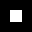

In [10]:
from IPython.display import Image, display
import os

if os.path.exists('slice.png'):
    print("Displaying the rendered NIfTI slice:")
    display(Image('slice.png', width=200))
else:
    print("slice.png not found. Make sure the Rust code ran successfully.")

### 6. Visualize a Real NIfTI Image
First, let's download and extract the dataset.

In [11]:
!wget -qO- https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar | tar -xvf -
!ls Task09_Spleen/imagesTr | head -n 5

./._Task09_Spleen
Task09_Spleen/
Task09_Spleen/._labelsTr
Task09_Spleen/labelsTr/
Task09_Spleen/._imagesTr
Task09_Spleen/imagesTr/
Task09_Spleen/._imagesTs
Task09_Spleen/imagesTs/
Task09_Spleen/._dataset.json
Task09_Spleen/dataset.json
Task09_Spleen/imagesTs/._spleen_15.nii.gz
Task09_Spleen/imagesTs/spleen_15.nii.gz
Task09_Spleen/imagesTs/._spleen_23.nii.gz
Task09_Spleen/imagesTs/spleen_23.nii.gz
Task09_Spleen/imagesTs/._spleen_1.nii.gz
Task09_Spleen/imagesTs/spleen_1.nii.gz
Task09_Spleen/imagesTs/._spleen_42.nii.gz
Task09_Spleen/imagesTs/spleen_42.nii.gz
Task09_Spleen/imagesTs/._spleen_50.nii.gz
Task09_Spleen/imagesTs/spleen_50.nii.gz
Task09_Spleen/imagesTs/._spleen_54.nii.gz
Task09_Spleen/imagesTs/spleen_54.nii.gz
Task09_Spleen/imagesTs/._spleen_37.nii.gz
Task09_Spleen/imagesTs/spleen_37.nii.gz
Task09_Spleen/imagesTs/._spleen_58.nii.gz
Task09_Spleen/imagesTs/spleen_58.nii.gz
Task09_Spleen/imagesTs/._spleen_39.nii.gz
Task09_Spleen/imagesTs/spleen_39.nii.gz
Task09_Spleen/imagesTs/._spl

In [12]:
%%writefile src/main.rs
use nifti::{IntoNdArray, NiftiObject, ReaderOptions};
use image::{ImageBuffer, Luma};

fn main() {
    // Point to a real file from the downloaded dataset
    let file_path = "Task09_Spleen/imagesTr/spleen_10.nii.gz";
    println!("Loading NIfTI file: {}", file_path);

    // Read the NIfTI file and convert the volume to an ndarray
    let obj = ReaderOptions::new().read_file(file_path).expect("Failed to read NIfTI");
    let volume = obj.into_volume();
    let ndarray = volume.into_ndarray::<f32>().expect("Failed to convert to ndarray");

    let shape = ndarray.shape();
    println!("Data shape: {:?}", shape);

    let width = shape[0];
    let height = shape[1];
    let depth = shape[2];
    let z_slice = depth / 2; // Extract the middle slice

    // Find min and max values in this specific slice for normalization
    let mut min_val = f32::MAX;
    let mut max_val = f32::MIN;
    for x in 0..width {
        for y in 0..height {
            let val = ndarray[[x, y, z_slice]];
            if val < min_val { min_val = val; }
            if val > max_val { max_val = val; }
        }
    }

    println!("Slice Min: {}, Max: {}", min_val, max_val);

    // Create a new grayscale image buffer
    let mut imgbuf = ImageBuffer::new(width as u32, height as u32);

    for x in 0..width {
        for y in 0..height {
            let val = ndarray[[x, y, z_slice]];

            // Normalize the value to 0.0 - 1.0
            let mut norm = (val - min_val) / (max_val - min_val);
            if norm < 0.0 { norm = 0.0; }
            if norm > 1.0 { norm = 1.0; }

            // Scale to 0-255 for the image pixel
            let pixel_val = (norm * 255.0) as u8;
            imgbuf.put_pixel(x as u32, y as u32, Luma([pixel_val]));
        }
    }

    // Save the resulting slice as a PNG
    let output_file = "real_slice.png";
    imgbuf.save(output_file).expect("Failed to save image");
    println!("Successfully saved real middle slice to {}", output_file);
}


Overwriting src/main.rs


In [13]:
!cargo run

   Compiling nifti_viewer v0.1.0 (/content/nifti_viewer)
    Finished `dev` profile [unoptimized + debuginfo] target(s) in 0.61s
     Running `target/debug/nifti_viewer`
Loading NIfTI file: Task09_Spleen/imagesTr/spleen_10.nii.gz
Data shape: [512, 512, 55]
Slice Min: -1024, Max: 3072
Successfully saved real middle slice to real_slice.png


Displaying the rendered real NIfTI slice:


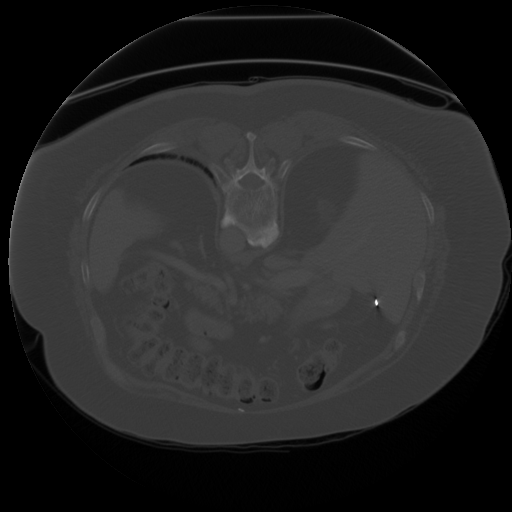

In [14]:
from IPython.display import Image, display
import os

if os.path.exists('real_slice.png'):
    print("Displaying the rendered real NIfTI slice:")
    display(Image('real_slice.png', width=400))
else:
    print("real_slice.png not found. Make sure the Rust code ran successfully.")

### 7. Run Spleen Segmentation Inference (MONAI)
Make sure to upload your `best_metric_model.pth` from your previous training session into the current directory before running the following code.

In [15]:
!pip install -q "monai[nibabel]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 51.4 MB/s eta 0:00:00


Model weights found! Setting up the MONAI UNet...
Running inference...


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out

Inference complete! Output shape: (253, 253, 94)


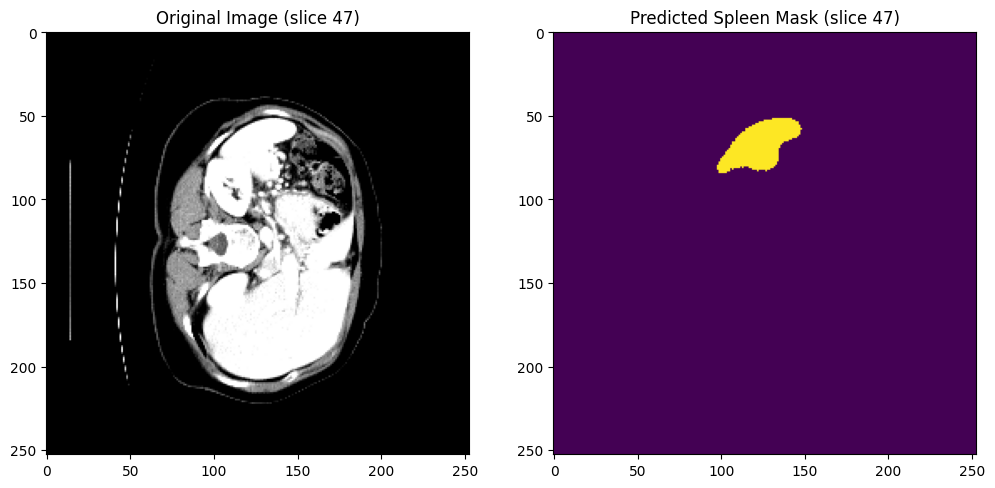

In [21]:
import os
import torch
import matplotlib.pyplot as plt
import monai
from monai.networks.nets import UNet
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityRanged,
    EnsureTyped,
)
from monai.inferers import sliding_window_inference

model_path = "/content/best_metric_model.pth"

if not os.path.exists(model_path):
    print(f"⚠️ Please upload your trained '{model_path}' to the current directory!")
else:
    print("Model weights found! Setting up the MONAI UNet...")

    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize UNet with norm="instance" which is common if BatchNorm wasn't used
    model = UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=2,
        channels=(16, 32, 64, 128, 256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
        norm="instance",  # Changed from "batch" to "instance"
    ).to(device)

    # Load the trained weights
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except RuntimeError as e:
        print("Still getting a mismatch. Let's inspect the state_dict keys:")
        sd = torch.load(model_path, map_location=device)
        print(list(sd.keys())[:10])
        raise e

    model.eval()

    # Apply the same preprocessing transforms used during validation
    val_transforms = Compose([
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
        Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear")),
        ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
        EnsureTyped(keys=["image"]),
    ])

    # Pick an image from the test set
    test_image_path = "Task09_Spleen/imagesTs/spleen_15.nii.gz"
    data = {"image": test_image_path}
    data = val_transforms(data)

    # Add batch dimension and move to device
    inputs = data["image"].unsqueeze(0).to(device)

    print("Running inference...")
    with torch.no_grad():
        outputs = sliding_window_inference(inputs, (160, 160, 160), 4, model)
        # Argmax to get the discrete segmentation mask
        pred_mask = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()

    original_image = data["image"].squeeze().cpu().numpy()

    print(f"Inference complete! Output shape: {pred_mask.shape}")

    # Plotting the middle slice
    slice_idx = pred_mask.shape[2] // 2
    plt.figure("check", (12, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Image (slice {slice_idx})")
    plt.imshow(original_image[:, :, slice_idx], cmap="gray")

    plt.subplot(1, 2, 2)
    plt.title(f"Predicted Spleen Mask (slice {slice_idx})")
    plt.imshow(pred_mask[:, :, slice_idx], cmap="viridis")
    plt.show()

### 8. Combine Python Inference with Rust Visualization
First, let's take the prediction mask from MONAI and save it back to disk as a NIfTI file using `nibabel`.

In [22]:
import nibabel as nib
import numpy as np

# pred_mask is the numpy array generated by MONAI in the previous cell
# We save it as a new NIfTI file.
pred_nifti = nib.Nifti1Image(pred_mask.astype(np.int16), np.eye(4))
output_filename = 'prediction_mask.nii.gz'
nib.save(pred_nifti, output_filename)

print(f"Saved inference output to {output_filename}")

Saved inference output to prediction_mask.nii.gz


Next, let's update our Rust program to accept a file path via command-line arguments. It will read the NIfTI mask and save it as an image.

In [23]:
%%writefile src/main.rs
use nifti::{IntoNdArray, NiftiObject, ReaderOptions};
use image::{ImageBuffer, Luma};
use std::env;

fn main() {
    // 1. Get the file path from command line arguments
    let args: Vec<String> = env::args().collect();
    if args.len() < 2 {
        eprintln!("Usage: {} <path_to_nifti_file>", args[0]);
        std::process::exit(1);
    }
    let file_path = &args[1];
    println!("Rust: Loading NIfTI file: {}", file_path);

    // 2. Read the NIfTI file
    let obj = ReaderOptions::new().read_file(file_path).expect("Failed to read NIfTI");
    let volume = obj.into_volume();
    let ndarray = volume.into_ndarray::<f32>().expect("Failed to convert to ndarray");

    let shape = ndarray.shape();
    println!("Rust: Data shape: {:?}", shape);

    // 3. Extract the middle slice
    let width = shape[0];
    let height = shape[1];
    let depth = shape[2];
    let z_slice = depth / 2;

    let mut imgbuf = ImageBuffer::new(width as u32, height as u32);

    // 4. Render the slice (Assuming values are 0 for background, 1 for spleen)
    for x in 0..width {
        for y in 0..height {
            let val = ndarray[[x, y, z_slice]];
            // Map 1.0 (spleen) to 255 (white) and 0.0 to 0 (black)
            let pixel_val: u8 = if val > 0.5 { 255 } else { 0 };
            imgbuf.put_pixel(x as u32, y as u32, Luma([pixel_val]));
        }
    }

    // 5. Save the output
    let output_file = "rust_output.png";
    imgbuf.save(output_file).expect("Failed to save image");
    println!("Rust: Successfully saved rendered mask to {}", output_file);
}

Overwriting src/main.rs


Now we compile the Rust tool and pass our newly generated `prediction_mask.nii.gz` to it.

In [24]:
!cargo run -- prediction_mask.nii.gz

   Compiling nifti_viewer v0.1.0 (/content/nifti_viewer)
    Finished `dev` profile [unoptimized + debuginfo] target(s) in 0.97s
     Running `target/debug/nifti_viewer prediction_mask.nii.gz`
Rust: Loading NIfTI file: prediction_mask.nii.gz
Rust: Data shape: [253, 253, 94]
Rust: Successfully saved rendered mask to rust_output.png


Python: Displaying the image generated by Rust:


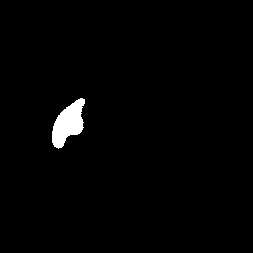

In [25]:
from IPython.display import Image, display
import os

if os.path.exists('rust_output.png'):
    print("Python: Displaying the image generated by Rust:")
    display(Image('rust_output.png', width=300))
else:
    print("Image not found. Check the Rust execution step.")

### 9. Overlay Visualization in Python
Let's visualize the exact overlay of the predicted mask on the original image.

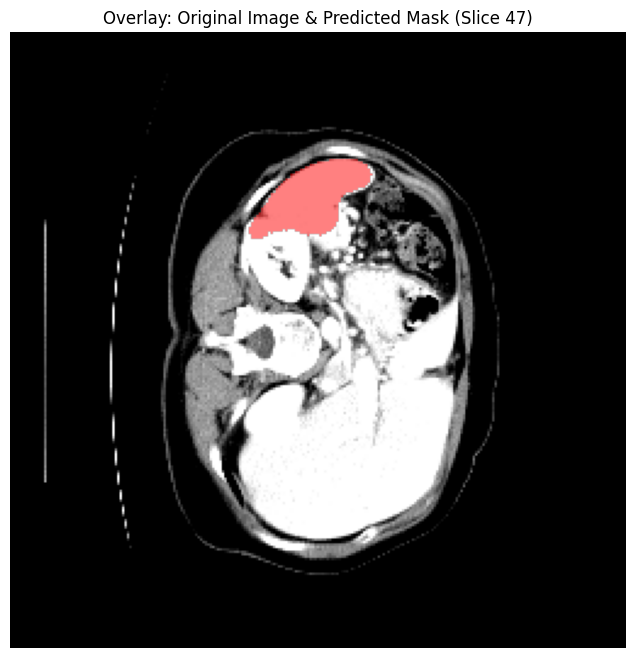

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# We already have `original_image` and `pred_mask` from the MONAI inference cell
slice_idx = pred_mask.shape[2] // 2

plt.figure(figsize=(8, 8))
plt.title(f"Overlay: Original Image & Predicted Mask (Slice {slice_idx})")

# 1. Plot the original image in grayscale
plt.imshow(original_image[:, :, slice_idx], cmap="gray")

# 2. Mask the background (0 values) so only the spleen prediction (1 values) is visible
mask_overlay = np.ma.masked_where(pred_mask[:, :, slice_idx] == 0, pred_mask[:, :, slice_idx])

# 3. Plot the mask overlay with a distinct colormap and some transparency (alpha)
plt.imshow(mask_overlay, cmap="autumn", alpha=0.5)

plt.axis('off')
plt.show()

### 10. Unified End-to-End Pipeline
Let's create a single wrapper script that takes an input image, runs the AI model, and then calls Rust to render it.

In [28]:
%%writefile pipeline.py
import sys
import os
import torch
import numpy as np
import nibabel as nib
import subprocess
from monai.networks.nets import UNet
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Spacingd, ScaleIntensityRanged, EnsureTyped
)
from monai.inferers import sliding_window_inference

if len(sys.argv) < 2:
    print("Usage: python pipeline.py <input_nifti_image>")
    sys.exit(1)

input_image_path = sys.argv[1]
model_path = "/content/best_metric_model.pth"
output_mask_path = "prediction_mask.nii.gz"

if not os.path.exists(model_path):
    print(f"Error: Model not found at {model_path}")
    sys.exit(1)

print(f"\n[Python] --- Step 1: Running AI Inference on {input_image_path} ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(
    spatial_dims=3, in_channels=1, out_channels=2,
    channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2),
    num_res_units=2, norm="instance"
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    EnsureTyped(keys=["image"]),
])

data = val_transforms({"image": input_image_path})
inputs = data["image"].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = sliding_window_inference(inputs, (160, 160, 160), 4, model)
    pred_mask = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()

# Save mask to disk
pred_nifti = nib.Nifti1Image(pred_mask.astype(np.int16), np.eye(4))
nib.save(pred_nifti, output_mask_path)
print(f"[Python] Mask saved to {output_mask_path}")

print(f"\n[Python] --- Step 2: Running Rust Renderer on {output_mask_path} ---")
# Call the Rust tool via subprocess
subprocess.run(["cargo", "run", "--", output_mask_path], check=True)
print("\n[Python] --- Pipeline Complete ---")


Writing pipeline.py


Now you can run the entire process in one single line by passing any image from the dataset. Let's try it with a different image, for example `spleen_23.nii.gz`.

In [42]:
!python pipeline.py Task09_Spleen/imagesTs/spleen_23.nii.gz

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.

[Python] --- Step 1: Running AI Inference on Task09_Spleen/imagesTs/spleen_23.nii.gz ---
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be ch

Final Pipeline Result:


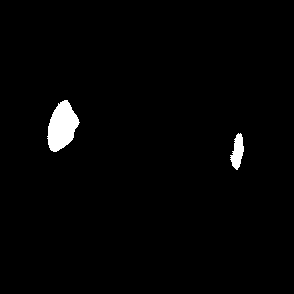

In [43]:
from IPython.display import Image, display
import os

if os.path.exists('rust_output.png'):
    print("Final Pipeline Result:")
    display(Image('rust_output.png', width=300))
else:
    print("Image not found.")

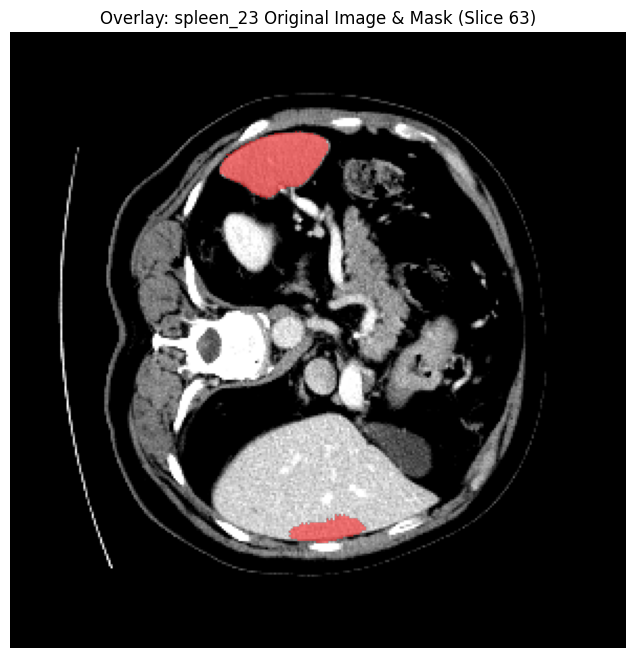

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
from monai.transforms import LoadImaged, EnsureChannelFirstd, Spacingd, ScaleIntensityRanged, EnsureTyped, Compose

# Re-apply the same transforms to get the original image in the right dimensions
val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    EnsureTyped(keys=["image"]),
])

# Load the specific image we just ran through the pipeline
data = val_transforms({"image": "Task09_Spleen/imagesTs/spleen_23.nii.gz"})
original_image_new = data["image"].squeeze().cpu().numpy()

# Load the mask saved by the pipeline
pred_mask_new = nib.load('prediction_mask.nii.gz').get_fdata()

slice_idx_new = pred_mask_new.shape[2] // 2

plt.figure(figsize=(8, 8))
plt.title(f"Overlay: spleen_23 Original Image & Mask (Slice {slice_idx_new})")

# 1. Plot the original image in grayscale
plt.imshow(original_image_new[:, :, slice_idx_new], cmap="gray")

# 2. Mask the background (0 values)
mask_overlay_new = np.ma.masked_where(pred_mask_new[:, :, slice_idx_new] == 0, pred_mask_new[:, :, slice_idx_new])

# 3. Plot the mask overlay
plt.imshow(mask_overlay_new, cmap="autumn", alpha=0.5)

plt.axis('off')
plt.show()